# **Get the files into Colab**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train_FD001.txt to train_FD001.txt
Saving RUL_FD001.txt to RUL_FD001.txt
Saving test_FD001.txt to test_FD001.txt


**Load and name the columns properly**

In [ ]:
import pandas as pd

index_names = ['unit_number', 'time_cycles']
setting_names = ['setting_1', 'setting_2', 'setting_3']
sensor_names = [f'sensor_{i}' for i in range(1, 22)]
col_names = index_names + setting_names + sensor_names

# sep=r'\s+' handles the irregular whitespace; header=None because there's no header row
train = pd.read_csv('train_FD001.txt', sep=r'\s+', header=None, names=col_names)
test = pd.read_csv('test_FD001.txt', sep=r'\s+', header=None, names=col_names)
rul_test = pd.read_csv('RUL_FD001.txt', sep=r'\s+', header=None, names=['RUL'])
print(train.shape)
print(train.head())

(20631, 26)
   unit_number  time_cycles  setting_1  setting_2  setting_3  sensor_1  \
0            1            1    -0.0007    -0.0004      100.0    518.67   
1            1            2     0.0019    -0.0003      100.0    518.67   
2            1            3    -0.0043     0.0003      100.0    518.67   
3            1            4     0.0007     0.0000      100.0    518.67   
4            1            5    -0.0019    -0.0002      100.0    518.67   

   sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  \
0    641.82   1589.70   1400.60     14.62  ...     521.66    2388.02   
1    642.15   1591.82   1403.14     14.62  ...     522.28    2388.07   
2    642.35   1587.99   1404.20     14.62  ...     522.42    2388.03   
3    642.35   1582.79   1401.87     14.62  ...     522.86    2388.08   
4    642.37   1582.85   1406.22     14.62  ...     522.19    2388.04   

   sensor_14  sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  \
0    8138.62     8.4195       0.03     

**Sanity-check the structure**

In [ ]:
print(train.tail())
print(test.tail())
print(rul_test.tail())

       unit_number  time_cycles  setting_1  setting_2  setting_3  sensor_1  \
20626          100          196    -0.0004    -0.0003      100.0    518.67   
20627          100          197    -0.0016    -0.0005      100.0    518.67   
20628          100          198     0.0004     0.0000      100.0    518.67   
20629          100          199    -0.0011     0.0003      100.0    518.67   
20630          100          200    -0.0032    -0.0005      100.0    518.67   

       sensor_2  sensor_3  sensor_4  sensor_5  ...  sensor_12  sensor_13  \
20626    643.49   1597.98   1428.63     14.62  ...     519.49    2388.26   
20627    643.54   1604.50   1433.58     14.62  ...     519.68    2388.22   
20628    643.42   1602.46   1428.18     14.62  ...     520.01    2388.24   
20629    643.23   1605.26   1426.53     14.62  ...     519.67    2388.23   
20630    643.85   1600.38   1432.14     14.62  ...     519.30    2388.26   

       sensor_14  sensor_15  sensor_16  sensor_17  sensor_18  sensor_19  \

In [ ]:
print("Number of engines in training set:", train['unit_number'].nunique())
print("Cycles per engine (first 5 engines):")
print(train.groupby('unit_number')['time_cycles'].max().head())

Number of engines in training set: 100
Cycles per engine (first 5 engines):
unit_number
1    192
2    287
3    179
4    189
5    269
Name: time_cycles, dtype: int64


# **Compute RUL for the training set**

In [ ]:
# Get max cycle per engine
max_cycles = train.groupby('unit_number')['time_cycles'].max().rename('max_cycle')

# Merge back onto the full training dataframe
train = train.merge(max_cycles, on='unit_number', how='left')

# RUL = max cycle for that engine - current cycle
train['RUL'] = train['max_cycle'] - train['time_cycles']

# Drop the helper column, we don't need it anymore
train.drop('max_cycle', axis=1, inplace=True)

print(train[['unit_number', 'time_cycles', 'RUL']].head(10))
print(train[['unit_number', 'time_cycles', 'RUL']].tail(5))

   unit_number  time_cycles  RUL
0            1            1  191
1            1            2  190
2            1            3  189
3            1            4  188
4            1            5  187
5            1            6  186
6            1            7  185
7            1            8  184
8            1            9  183
9            1           10  182
       unit_number  time_cycles  RUL
20626          100          196    4
20627          100          197    3
20628          100          198    2
20629          100          199    1
20630          100          200    0


In [ ]:
RUL_CAP = 125
train['RUL'] = train['RUL'].clip(upper=RUL_CAP)

In [ ]:
print(train[['unit_number', 'time_cycles', 'RUL']].head(10))

   unit_number  time_cycles  RUL
0            1            1  191
1            1            2  190
2            1            3  189
3            1            4  188
4            1            5  187
5            1            6  186
6            1            7  185
7            1            8  184
8            1            9  183
9            1           10  182


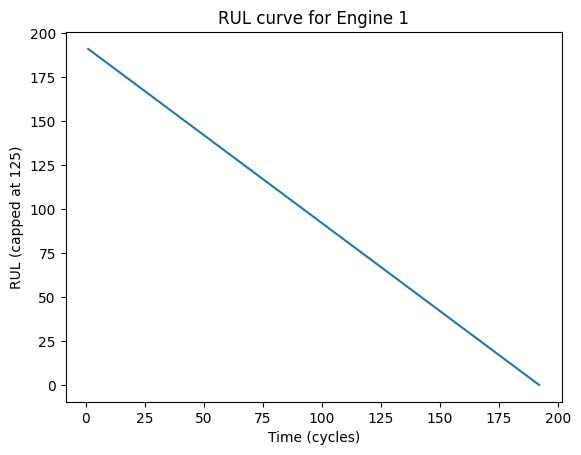

In [ ]:
import matplotlib.pyplot as plt

engine_1 = train[train['unit_number'] == 1]
plt.plot(engine_1['time_cycles'], engine_1['RUL'])
plt.xlabel('Time (cycles)')
plt.ylabel('RUL (capped at 125)')
plt.title('RUL curve for Engine 1')
plt.show()

# **Building Sliding-Window Sequences**

In [ ]:
SEQUENCE_LENGTH = 30  # 30 cycles of history per training example — common starting choice for CMAPSS

# Use sensor columns only as features for now (settings can be added later if needed)
feature_cols = sensor_names  # the sensor_1 ... sensor_21 list from Step 2

In [ ]:
import numpy as np

def create_sequences(df, sequence_length, feature_cols, label_col='RUL'):
    sequences = []
    labels = []

    for engine_id in df['unit_number'].unique():
        engine_df = df[df['unit_number'] == engine_id].reset_index(drop=True)
        data = engine_df[feature_cols].values
        rul = engine_df[label_col].values

        # Only create windows if the engine has enough cycles
        if len(engine_df) < sequence_length:
            continue

        for i in range(len(engine_df) - sequence_length + 1):
            seq = data[i : i + sequence_length]
            label = rul[i + sequence_length - 1]  # RUL at the LAST cycle in the window
            sequences.append(seq)
            labels.append(label)

    return np.array(sequences), np.array(labels)

X_train, y_train = create_sequences(train, SEQUENCE_LENGTH, feature_cols)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (17731, 30, 21)
y_train shape: (17731,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training sensor values, then transform training data
train[feature_cols] = scaler.fit_transform(train[feature_cols])

print(train[feature_cols].describe().loc[['mean', 'std']])

      sensor_1      sensor_2      sensor_3      sensor_4      sensor_5  \
mean       0.0  6.410348e-14 -4.959437e-14  9.285169e-16 -1.776357e-15   
std        0.0  1.000024e+00  1.000024e+00  1.000024e+00  0.000000e+00   

          sensor_6      sensor_7      sensor_8      sensor_9  sensor_10  ...  \
mean -6.469426e-12 -3.161641e-14  1.008249e-12 -4.185765e-14        0.0  ...   
std   1.000024e+00  1.000024e+00  1.000024e+00  1.000024e+00        0.0  ...   

         sensor_12     sensor_13     sensor_14     sensor_15     sensor_16  \
mean -1.199702e-13  3.493855e-13  3.061075e-15 -3.244023e-14 -1.387779e-17   
std   1.000024e+00  1.000024e+00  1.000024e+00  1.000024e+00  0.000000e+00   

         sensor_17  sensor_18  sensor_19     sensor_20     sensor_21  
mean  1.666922e-14        0.0        0.0  4.156146e-14  2.402296e-14  
std   1.000024e+00        0.0        0.0  1.000024e+00  1.000024e+00  

[2 rows x 21 columns]


In [ ]:
test[feature_cols] = scaler.transform(test[feature_cols])

In [ ]:
X_train, y_train = create_sequences(train, SEQUENCE_LENGTH, feature_cols)
print("X_train shape:", X_train.shape)
print("Sample scaled values (first window, first cycle):", X_train[0, 0, :5])

X_train shape: (17731, 30, 21)
Sample scaled values (first window, first cycle): [ 0.00000000e+00 -1.72172539e+00 -1.34255176e-01 -9.25935964e-01
 -1.77635684e-15]


In [ ]:
# Identify constant sensors (zero variance) using the ORIGINAL unscaled training data
# (re-load or check before scaling — if you've already overwritten `train`, check std == 0 from your describe() output above)

constant_sensors = ['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
# ^ this is the standard known list for FD001 — but confirm against YOUR describe() output, don't just trust this blindly

feature_cols = [c for c in sensor_names if c not in constant_sensors]
print("Remaining feature count:", len(feature_cols))

Remaining feature count: 14


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train[feature_cols] = scaler.fit_transform(train[feature_cols])
print(train[feature_cols].describe().loc[['mean', 'std']])

test[feature_cols] = scaler.transform(test[feature_cols])

X_train, y_train = create_sequences(train, SEQUENCE_LENGTH, feature_cols)
print("X_train shape:", X_train.shape)
print("Sample scaled values (first window, first cycle):", X_train[0, 0, :5])

          sensor_2      sensor_3      sensor_4      sensor_7      sensor_8  \
mean -5.510486e-18  8.265729e-18  2.341957e-17  1.377622e-18 -2.755243e-18   
std   1.000024e+00  1.000024e+00  1.000024e+00  1.000024e+00  1.000024e+00   

          sensor_9     sensor_11     sensor_12     sensor_13     sensor_14  \
mean  8.265729e-18  1.377622e-18 -2.755243e-17  3.857340e-17  9.643351e-18   
std   1.000024e+00  1.000024e+00  1.000024e+00  1.000024e+00  1.000024e+00   

         sensor_15     sensor_17     sensor_20     sensor_21  
mean -1.102097e-17  2.204194e-17  1.515384e-17  2.204194e-17  
std   1.000024e+00  1.000024e+00  1.000024e+00  1.000024e+00  
X_train shape: (17731, 30, 14)
Sample scaled values (first window, first cycle): [-1.72172539 -0.13425518 -0.92593596  1.12114057 -0.51633841]


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class CMAPSSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = CMAPSSDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

print("Number of batches:", len(train_loader))

Number of batches: 278


In [ ]:
class RULPredictor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x shape: (batch, sequence_length, input_size)
        lstm_out, (hidden, cell) = self.lstm(x)
        # hidden shape: (num_layers, batch, hidden_size) — take the LAST layer's hidden state
        last_hidden = hidden[-1]  # shape: (batch, hidden_size)
        out = self.fc(last_hidden)  # shape: (batch, 1)
        return out.squeeze(-1)  # shape: (batch,)

input_size = len(feature_cols)  # 14
model = RULPredictor(input_size=input_size)
print(model)

RULPredictor(
  (lstm): LSTM(14, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [ ]:
sample_X, sample_y = next(iter(train_loader))
print("Input batch shape:", sample_X.shape)
output = model(sample_X)
print("Output shape:", output.shape)
print("Sample predictions (untrained, will be random):", output[:5])

Input batch shape: torch.Size([64, 30, 14])
Output shape: torch.Size([64])
Sample predictions (untrained, will be random): tensor([-0.1760, -0.1740, -0.1672, -0.1694, -0.1654], grad_fn=<SliceBackward0>)


In [ ]:
import torch.optim as optim

criterion = nn.MSELoss()  # Mean Squared Error — standard for regression tasks like RUL
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print("Using device:", device)

Using device: cpu


In [ ]:
num_epochs = 30

for epoch in range(num_epochs):
    model.train()  # sets model to training mode (activates dropout)
    total_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer.zero_grad()          # clear gradients from previous step
        predictions = model(batch_X)   # forward pass
        loss = criterion(predictions, batch_y)  # compute MSE loss
        loss.backward()                # backward pass — compute gradients
        optimizer.step()               # update weights using gradients

        total_loss += loss.item() * batch_X.size(0)

    avg_loss = total_loss / len(train_dataset)
    rmse = avg_loss ** 0.5  # RMSE is more interpretable than MSE (same units as RUL)

    print(f"Epoch {epoch+1}/{num_epochs} — MSE: {avg_loss:.2f}, RMSE: {rmse:.2f}")

Epoch 1/30 — MSE: 10507.20, RMSE: 102.50
Epoch 2/30 — MSE: 7906.11, RMSE: 88.92
Epoch 3/30 — MSE: 6064.21, RMSE: 77.87
Epoch 4/30 — MSE: 4705.05, RMSE: 68.59
Epoch 5/30 — MSE: 3692.55, RMSE: 60.77
Epoch 6/30 — MSE: 2942.45, RMSE: 54.24
Epoch 7/30 — MSE: 2386.14, RMSE: 48.85
Epoch 8/30 — MSE: 1972.16, RMSE: 44.41
Epoch 9/30 — MSE: 1665.65, RMSE: 40.81
Epoch 10/30 — MSE: 1430.06, RMSE: 37.82
Epoch 11/30 — MSE: 1273.28, RMSE: 35.68
Epoch 12/30 — MSE: 1128.64, RMSE: 33.60
Epoch 13/30 — MSE: 1029.78, RMSE: 32.09
Epoch 14/30 — MSE: 978.02, RMSE: 31.27
Epoch 15/30 — MSE: 882.80, RMSE: 29.71
Epoch 16/30 — MSE: 821.27, RMSE: 28.66
Epoch 17/30 — MSE: 807.85, RMSE: 28.42
Epoch 18/30 — MSE: 728.88, RMSE: 27.00
Epoch 19/30 — MSE: 691.15, RMSE: 26.29
Epoch 20/30 — MSE: 639.46, RMSE: 25.29
Epoch 21/30 — MSE: 616.20, RMSE: 24.82
Epoch 22/30 — MSE: 570.62, RMSE: 23.89
Epoch 23/30 — MSE: 532.41, RMSE: 23.07
Epoch 24/30 — MSE: 490.75, RMSE: 22.15
Epoch 25/30 — MSE: 445.97, RMSE: 21.12
Epoch 26/30 — MSE: 

In [ ]:
def create_test_sequences(df, sequence_length, feature_cols):
    sequences = []
    engine_ids = []

    for engine_id in df['unit_number'].unique():
        engine_df = df[df['unit_number'] == engine_id].reset_index(drop=True)
        data = engine_df[feature_cols].values

        if len(engine_df) < sequence_length:
            # Pad short sequences by repeating the first row (rare edge case, but handle it)
            padding = np.repeat(data[0:1], sequence_length - len(data), axis=0)
            data = np.concatenate([padding, data], axis=0)

        # Take the LAST sequence_length cycles only
        last_seq = data[-sequence_length:]
        sequences.append(last_seq)
        engine_ids.append(engine_id)

    return np.array(sequences), engine_ids

X_test, test_engine_ids = create_test_sequences(test, SEQUENCE_LENGTH, feature_cols)
print("X_test shape:", X_test.shape)

X_test shape: (100, 30, 14)


In [ ]:
RUL_CAP = 125

true_rul = rul_test['RUL'].values
true_rul_capped = np.minimum(true_rul, RUL_CAP)

test_rmse = np.sqrt(np.mean((test_predictions - true_rul_capped) ** 2))
print("Test RMSE:", test_rmse)

comparison = pd.DataFrame({
    'engine_id': test_engine_ids,
    'true_RUL': true_rul_capped,
    'predicted_RUL': test_predictions
})
print(comparison.head(10))

Test RMSE: 30.660910164944152
   engine_id  true_RUL  predicted_RUL
0          1       112     159.998901
1          2        98     151.075638
2          3        69      37.612854
3          4        82     120.200829
4          5        91     117.912949
5          6        93     127.088776
6          7        91     119.285812
7          8        95     193.824142
8          9       111     118.375153
9         10        96      84.239487


In [ ]:
model.eval()  # turns off dropout — we want deterministic predictions now, not training-mode randomness

with torch.no_grad():  # disables gradient tracking — we're not training, just predicting, saves memory/compute
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    test_predictions = model(X_test_tensor).cpu().numpy()

# True RUL values, capped the same way as training (for fair comparison)
true_rul = rul_test['RUL'].values
true_rul_capped = np.minimum(true_rul, RUL_CAP)

test_rmse = np.sqrt(np.mean((test_predictions - true_rul_capped) ** 2))
print("Test RMSE:", test_rmse)

# Look at a handful of individual predictions vs actual
import pandas as pd
comparison = pd.DataFrame({
    'engine_id': test_engine_ids,
    'true_RUL': true_rul_capped,
    'predicted_RUL': test_predictions
})
print(comparison.head(10))

Test RMSE: 30.660910164944152
   engine_id  true_RUL  predicted_RUL
0          1       112     159.998901
1          2        98     151.075638
2          3        69      37.612854
3          4        82     120.200829
4          5        91     117.912949
5          6        93     127.088776
6          7        91     119.285812
7          8        95     193.824142
8          9       111     118.375153
9         10        96      84.239487


In [ ]:
errors = comparison['predicted_RUL'] - comparison['true_RUL']
print("Overestimates (dangerous — predicted more life than actual):", (errors > 0).sum())
print("Underestimates (conservative — predicted less life than actual):", (errors < 0).sum())
print("Mean error (positive = tends to overestimate):", errors.mean())

Overestimates (dangerous — predicted more life than actual): 69
Underestimates (conservative — predicted less life than actual): 31
Mean error (positive = tends to overestimate): 12.691025424003602


In [ ]:
import torch

class AsymmetricRULLoss(nn.Module):
    def __init__(self, over_penalty=2.0):
        """
        over_penalty: how much MORE we penalize overestimation vs underestimation.
        2.0 means overestimation errors are weighted twice as heavily.
        """
        super().__init__()
        self.over_penalty = over_penalty

    def forward(self, predictions, targets):
        diff = predictions - targets  # positive = overestimate, negative = underestimate
        squared_error = diff ** 2

        # Build a weight tensor: over_penalty where diff > 0, else 1.0
        weights = torch.where(diff > 0,
                               torch.tensor(self.over_penalty, device=diff.device),
                               torch.tensor(1.0, device=diff.device))

        weighted_error = weights * squared_error
        return weighted_error.mean()

In [ ]:
model_v2 = RULPredictor(input_size=input_size).to(device)
criterion_v2 = AsymmetricRULLoss(over_penalty=2.0)
optimizer_v2 = optim.Adam(model_v2.parameters(), lr=0.001)

num_epochs = 30

for epoch in range(num_epochs):
    model_v2.train()
    total_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)

        optimizer_v2.zero_grad()
        predictions = model_v2(batch_X)
        loss = criterion_v2(predictions, batch_y)
        loss.backward()
        optimizer_v2.step()

        total_loss += loss.item() * batch_X.size(0)

    avg_loss = total_loss / len(train_dataset)
    print(f"Epoch {epoch+1}/{num_epochs} — Weighted Loss: {avg_loss:.2f}")

Epoch 1/30 — Weighted Loss: 10541.57
Epoch 2/30 — Weighted Loss: 7890.90
Epoch 3/30 — Weighted Loss: 6031.70
Epoch 4/30 — Weighted Loss: 4667.45
Epoch 5/30 — Weighted Loss: 3662.87
Epoch 6/30 — Weighted Loss: 2924.45
Epoch 7/30 — Weighted Loss: 2399.69
Epoch 8/30 — Weighted Loss: 2017.07
Epoch 9/30 — Weighted Loss: 1739.30
Epoch 10/30 — Weighted Loss: 1534.79
Epoch 11/30 — Weighted Loss: 1387.13
Epoch 12/30 — Weighted Loss: 1280.20
Epoch 13/30 — Weighted Loss: 1189.60
Epoch 14/30 — Weighted Loss: 1132.97
Epoch 15/30 — Weighted Loss: 1088.67
Epoch 16/30 — Weighted Loss: 1038.18
Epoch 17/30 — Weighted Loss: 985.52
Epoch 18/30 — Weighted Loss: 933.55
Epoch 19/30 — Weighted Loss: 880.59
Epoch 20/30 — Weighted Loss: 856.89
Epoch 21/30 — Weighted Loss: 801.67
Epoch 22/30 — Weighted Loss: 740.81
Epoch 23/30 — Weighted Loss: 702.84
Epoch 24/30 — Weighted Loss: 655.88
Epoch 25/30 — Weighted Loss: 637.61
Epoch 26/30 — Weighted Loss: 683.64
Epoch 27/30 — Weighted Loss: 521.92
Epoch 28/30 — Weight

In [ ]:
model_v2.eval()
with torch.no_grad():
    test_predictions_v2 = model_v2(X_test_tensor).cpu().numpy()

test_rmse_v2 = np.sqrt(np.mean((test_predictions_v2 - true_rul_capped) ** 2))
errors_v2 = test_predictions_v2 - true_rul_capped

print("New Test RMSE:", test_rmse_v2)
print("Overestimates:", (errors_v2 > 0).sum())
print("Underestimates:", (errors_v2 < 0).sum())
print("Mean error (was +12.69 before):", errors_v2.mean())

New Test RMSE: 24.983940171765543
Overestimates: 56
Underestimates: 44
Mean error (was +12.69 before): 6.384005947113037


In [ ]:
torch.save(model_v2.state_dict(), 'plantsense_lstm_rul.pth')

from google.colab import files
files.download('plantsense_lstm_rul.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Reminder: `train` still has the RUL column and scaled feature_cols from before
healthy_data = train[train['RUL'] >= RUL_CAP]  # only rows deep in "healthy" territory

print("Healthy rows:", len(healthy_data))
print("Total training rows:", len(train))
print("Fraction healthy:", len(healthy_data) / len(train))

Healthy rows: 8131
Total training rows: 20631
Fraction healthy: 0.3941156512044981


In [ ]:
def create_autoencoder_sequences(df, sequence_length, feature_cols):
    sequences = []

    for engine_id in df['unit_number'].unique():
        engine_df = df[df['unit_number'] == engine_id].reset_index(drop=True)
        data = engine_df[feature_cols].values

        if len(engine_df) < sequence_length:
            continue  # skip engines that don't have enough healthy cycles for one window

        for i in range(len(engine_df) - sequence_length + 1):
            seq = data[i : i + sequence_length]
            sequences.append(seq)

    return np.array(sequences)

X_healthy = create_autoencoder_sequences(healthy_data, SEQUENCE_LENGTH, feature_cols)
print("X_healthy shape:", X_healthy.shape)

X_healthy shape: (5329, 30, 14)


In [ ]:
from sklearn.model_selection import train_test_split

X_healthy_train, X_healthy_val = train_test_split(X_healthy, test_size=0.2, random_state=42)

print("Training windows:", X_healthy_train.shape)
print("Validation windows:", X_healthy_val.shape)

Training windows: (4263, 30, 14)
Validation windows: (1066, 30, 14)


In [ ]:
# Flatten each window from (30, 14) into a single vector of length 420
n_timesteps = X_healthy_train.shape[1]  # 30
n_features = X_healthy_train.shape[2]   # 14
flattened_dim = n_timesteps * n_features  # 420

X_healthy_train_flat = X_healthy_train.reshape(X_healthy_train.shape[0], flattened_dim)
X_healthy_val_flat = X_healthy_val.reshape(X_healthy_val.shape[0], flattened_dim)

print("Flattened train shape:", X_healthy_train_flat.shape)
print("Flattened val shape:", X_healthy_val_flat.shape)

Flattened train shape: (4263, 420)
Flattened val shape: (1066, 420)


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

encoding_dim = 32  # the "bottleneck" — compressed representation size

autoencoder = keras.Sequential([
    layers.Input(shape=(flattened_dim,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(encoding_dim, activation='relu'),   # bottleneck layer
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(flattened_dim, activation='linear')  # output — reconstructs the original 420 values
])

autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │        53,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 420)            │        54,180 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,836 (503.27 KB)

 Trainable params: 128,836 (503.27 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = autoencoder.fit(
    X_healthy_train_flat, X_healthy_train_flat,   # input == target, this is the key autoencoder pattern
    validation_data=(X_healthy_val_flat, X_healthy_val_flat),
    epochs=50,
    batch_size=32,
    shuffle=True,
    verbose=1
)

Epoch 1/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.2856 - val_loss: 0.2314
Epoch 2/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2296 - val_loss: 0.2305
Epoch 3/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2283 - val_loss: 0.2291
Epoch 4/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2272 - val_loss: 0.2279
Epoch 5/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2260 - val_loss: 0.2274
Epoch 6/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2249 - val_loss: 0.2259
Epoch 7/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2238 - val_loss: 0.2254
Epoch 8/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2228 - val_loss: 0.2248
Epoch 9/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2219 - val_loss: 0.2243
Epoch 10/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2209 - val_loss: 0.2243
Epoch 11/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2201 - val_loss: 0.2234
Epoch 12/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

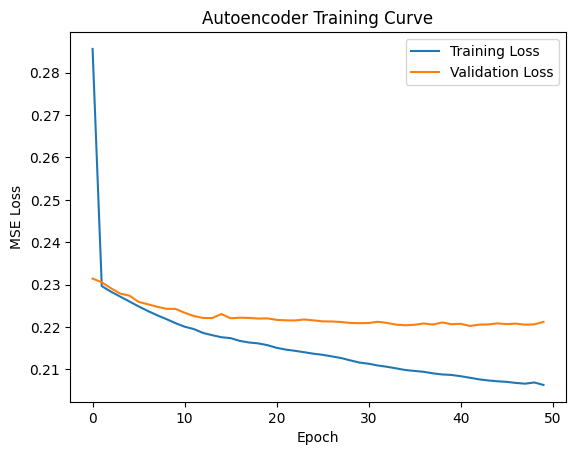

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Autoencoder Training Curve')
plt.show()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,          # stop if val_loss doesn't improve for 10 straight epochs
    restore_best_weights=True   # roll back to the best epoch's weights, not the last one
)

autoencoder_v2 = keras.Sequential([
    layers.Input(shape=(flattened_dim,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(encoding_dim, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(flattened_dim, activation='linear')
])
autoencoder_v2.compile(optimizer='adam', loss='mse')

history_v2 = autoencoder_v2.fit(
    X_healthy_train_flat, X_healthy_train_flat,
    validation_data=(X_healthy_val_flat, X_healthy_val_flat),
    epochs=50,
    batch_size=32,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.2849 - val_loss: 0.2316
Epoch 2/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2296 - val_loss: 0.2304
Epoch 3/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2283 - val_loss: 0.2287
Epoch 4/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2270 - val_loss: 0.2279
Epoch 5/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2254 - val_loss: 0.2264
Epoch 6/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2239 - val_loss: 0.2252
Epoch 7/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2224 - val_loss: 0.2246
Epoch 8/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2211 - val_loss: 0.2239
Epoch 9/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2199 - val_loss: 0.2236
Epoch 10/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.2192 - val_loss: 0.2229
Epoch 11/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.2180 - val_loss: 0.2225
Epoch 12/50
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

In [ ]:
val_reconstructions = autoencoder_v2.predict(X_healthy_val_flat)
val_reconstruction_error = np.mean(np.square(X_healthy_val_flat - val_reconstructions), axis=1)

print("Healthy validation reconstruction error stats:")
print("Mean:", val_reconstruction_error.mean())
print("Std:", val_reconstruction_error.std())
print("95th percentile:", np.percentile(val_reconstruction_error, 95))
print("99th percentile:", np.percentile(val_reconstruction_error, 99))

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Healthy validation reconstruction error stats:
Mean: 0.2205669610386049
Std: 0.01681558272546425
95th percentile: 0.24833283701059583
99th percentile: 0.26071631688040475


In [ ]:
THRESHOLD = np.percentile(val_reconstruction_error, 95)  # start with 95th percentile
print("Anomaly threshold set to:", THRESHOLD)

Anomaly threshold set to: 0.24833283701059583


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


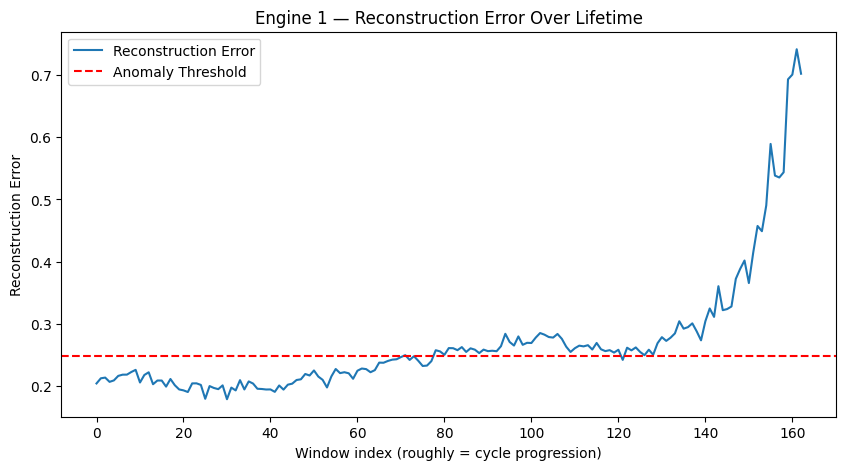

Number of windows flagged as anomalous: 86 out of 163


In [ ]:
# Build sequences for one full engine (e.g., engine 1), across its ENTIRE lifetime (not just healthy rows)
engine_1_full = train[train['unit_number'] == 1].reset_index(drop=True)
X_engine_1 = create_autoencoder_sequences(engine_1_full, SEQUENCE_LENGTH, feature_cols)
X_engine_1_flat = X_engine_1.reshape(X_engine_1.shape[0], flattened_dim)

engine_1_reconstructions = autoencoder_v2.predict(X_engine_1_flat)
engine_1_error = np.mean(np.square(X_engine_1_flat - engine_1_reconstructions), axis=1)

plt.figure(figsize=(10, 5))
plt.plot(engine_1_error, label='Reconstruction Error')
plt.axhline(y=THRESHOLD, color='r', linestyle='--', label='Anomaly Threshold')
plt.xlabel('Window index (roughly = cycle progression)')
plt.ylabel('Reconstruction Error')
plt.title('Engine 1 — Reconstruction Error Over Lifetime')
plt.legend()
plt.show()

print("Number of windows flagged as anomalous:", (engine_1_error > THRESHOLD).sum(), "out of", len(engine_1_error))

In [ ]:
# Find the window index where flagging FIRST becomes persistent (not just a one-off blip)
flagged = engine_1_error > THRESHOLD
first_flag_idx = np.argmax(flagged)  # index of first True
print("First window flagged as anomalous:", first_flag_idx, "out of", len(engine_1_error))
print("Corresponds to roughly cycle:", first_flag_idx + SEQUENCE_LENGTH)  # since first window covers cycles 1-30

First window flagged as anomalous: 71 out of 163
Corresponds to roughly cycle: 101


In [ ]:
autoencoder_v2.save('plantsense_autoencoder.keras')

from google.colab import files
files.download('plantsense_autoencoder.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>